# Session 1 walkthrough: data point, feature, label, model, loss, ERM

MLR1ILV, IMC Krems, WS26/27. **Instructor notebook**, run live in Session 1 next to
`session1-slides.pdf`.

**Run it:**

```
uv run --with numpy --with pillow --with matplotlib --with scikit-learn --with jupyter \
       jupyter lab sessions/session1-walkthrough.ipynb
```

It fetches its own data: eight map tiles from basemap.at and 114 parcel outlines from INVEKOS,
six seconds, once. The three files it writes land next to the notebook and are read again on
every later run --- the photograph, the INVEKOS marking, and `wachau_small_parcels.geojson`, the
parcel answer exactly as it arrived, which section 0b reads apart. Nothing has to be prepared
beforehand.

> **Say this out loud when you open it:** you hand in `.py` files, not notebooks. A notebook
> hides the order the cells ran in, and that hides mistakes. This one exists so we can stop
> after every line and look at what came out. Your own work runs as `uv run A1.py`.

**How to use it:** one section per slide beat. Before running a cell, ask the room to predict
the number. Then run it.

**The rectangle, and the deck.** This notebook works on a 992 x 384 rectangle, a hundredth of
the strip, so that no cell takes longer than a second and we can afford to run everything
twice. **Session 1's slides are measured on that same rectangle**: every number they show is a
number printed below, including the two patches on the hypothesis slide. A1 is the exception,
and the deck says so twice: it runs on the whole 9216 x 4608 strip, 41,472 patches. Set
`RECT = None` in the first code cell to work on the strip here too. That needs
`uv run get_wachau_photo.py` first, and every cell below then takes about a hundred times
longer. If you change the rectangle, re-measure the deck: `refsol/make_rectangle_assets.py`
rebuilds its four pictures, and `refsol/data/README-wachau-image.md` lists every number to
carry across.

## 0. Where the data comes from

Two public sources, each built by somebody for a purpose that is not ours.

- **The photograph:** basemap.at, the orthophoto service of the Austrian federal states. Map
  services cut the world into 256 x 256 pixel tiles addressed by a zoom level and two
  indices x and y.
  We ask for 4 x 2 tiles at zoom level 17, which is 0.79 m per pixel, and paste them into one
  image. The `google3857` in the tile URL names the grid they are cut on.
- **The INVEKOS marking:** INVEKOS, the register in which every Austrian farmer declares the fields
  they farm in order to be paid, published as open data by AgrarMarkt Austria. We ask for
  every parcel inside our box and draw each outline onto the photograph's pixel grid: 1 where
  the declared crop is WEIN, 2 for any other crop. **Ground nobody declared keeps the 0.**

That last sentence is the whole second half of today. Leave it on screen while the cell runs.

Both arrive as **numpy arrays**, and that is how they stay for the rest of the notebook: the
photograph as **HEIGHT x WIDTH x 3**, one number per colour channel per pixel, and the INVEKOS marking as
**HEIGHT x WIDTH**, one marking number per pixel. Same height, same width, so the pixel at a given place
in the one belongs to the pixel at that place in the other.

The rectangle is 992 x 384 pixels, which is 790 x 305 m on the south bank at Rossatz:
terraces along the top, forest across the bottom, roofs and a road on the right.

*Datenquelle: basemap.at (CC BY 4.0); INVEKOS Schläge 2025, AMA (CC BY 3.0 AT)*

In [3]:
import collections          # counting how often each declared crop occurs
import io                    # turning downloaded bytes into something Pillow can open
import json                  # the parcels arrive as JSON text
import math                  # the map projection is four lines of trigonometry
import sys                   # sys.exit, for the one case we cannot recover from
import time                  # timing the two cells that do real work
import urllib.request        # the standard library's HTTP client; no extra package needed
from pathlib import Path     # file paths that behave the same on macOS, Windows and Linux

import numpy as np           # every image in this notebook is a numpy array
from PIL import Image, ImageDraw   # reading and writing images, and drawing the parcels

Image.MAX_IMAGE_PIXELS = None          # the whole strip is 42 megapixels; Pillow refuses by default
np.set_printoptions(suppress=True)

# --- the rectangle we work on today ----------------------------------------------------
RECT = (992, 384)      # 1000 x 400, rounded down to whole 32-pixel patches.
                       # RECT = None works on the whole 9216 x 4608 strip instead: the numbers
                       # on the slides, about a hundred times the work, and it needs
                       # `uv run get_wachau_photo.down` to have written the two big files.
ZOOM, TILE = 17, 256   # basemap.at serves 256 x 256 px tiles; zoom 17 is 0.79 m per pixel
TX, TY = 71182, 45350  # the tile at the north-west corner of the rectangle
NX, NY = 4, 2          # 4 x 2 tiles = 1024 x 512 px, cropped down to RECT
STRIP_TILE = (71161, 45337)            # the north-west tile of the whole strip

ORTHO_URL = "https://mapsneu.wien.gv.at/basemap/bmaporthofoto30cm/normal/google3857/{z}/{y}/{x}.jpeg"
INVEKOS_URL = ("https://gis.lfrz.gv.at/api/geodata/i009501/ogc/features/v1/collections/"
               "i009501:invekos_schlaege_2025_1_polygon/items")
HEADERS = {"User-Agent": "MLR1ILV-course/1.0 (IMC Krems teaching material)"}


def find(name):
    """Look for a data file next to the notebook, in the folder above, and in refsol/data."""
    here = Path.cwd()                           # wherever the kernel was started
    for d in (here, here / "sessions", here.parent, here / "refsol" / "data",
              here.parent / "refsol" / "data"):
        if (d / name).exists():                 # the first place that has it wins
            return d / name
    return None                                 # not found: the caller decides what that means


def tile_deg(tile_across, tile_down):
    """Latitude and longitude of the north-west corner of a tile, at our zoom level."""
    n = 2 ** ZOOM                               # the world is n x n tiles at this zoom level
    # Longitude is a straight proportion of the way across; latitude comes back through the
    # Mercator formula, which is why it needs sinh and atan rather than a division.
    return (math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * tile_down / n)))),
            tile_across / n * 360 - 180)


def to_pixel(lat, lon):
    """Where the point lat, lon lands on the rectangle: across and down, in pixels."""
    n = 2 ** ZOOM                               # same tile grid as tile_deg, read the other way
    across = (lon + 180) / 360 * n                  # longitude -> tile number across, with fraction
    # latitude -> tile number down. This is the Mercator projection itself, in one line.
    down = (1 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2 * n
    # Subtract our own top-left tile, multiply by 256, and the answer is in pixels of OUR image.
    return (across - TX) * TILE, (down - TY) * TILE


def fetch(url, tries=4, timeout=60, with_headers=False):
    """One download, retried a few times: a single request to a public service can time out."""
    for k in range(tries):                      # up to `tries` attempts, then give up
        try:
            answer = urllib.request.urlopen(urllib.request.Request(url, headers=HEADERS), timeout=timeout)
            # .read() is the body. The headers say things the body does not, such as the CRS.
            return (answer.read(), dict(answer.headers)) if with_headers else answer.read()
        except Exception:                                  # noqa: BLE001 -- any network error: wait, retry
            if k == tries - 1:                  # the last attempt failed: let the caller see it
                raise
            time.sleep(2 * (k + 1))             # wait longer before each retry: 2 s, 4 s, 6 s


def download_photo():
    """Paste the NX x NY tiles into one image and cut the rectangle out of it."""
    mosaic = Image.new("RGB", (NX * TILE, NY * TILE))   # an empty 1024 x 512 canvas
    for i in range(NX):                                # 4 tiles across
        for j in range(NY):                            # 2 tiles down
            # One HTTP request per tile: 8 in total. The service names its own indices x and y.
            # io.BytesIO lets Pillow read the bytes
            # as if they were a file on disk.
            tile = Image.open(io.BytesIO(fetch(ORTHO_URL.format(z=ZOOM, x=TX + i, y=TY + j))))
            mosaic.paste(tile, (i * TILE, j * TILE))       # tile (i, j) goes to pixel (i*256, j*256)
    return np.array(mosaic.crop((0, 0, *RECT)))            # cut 1024 x 512 down to 992 x 384


def download_marking():
    """Fetch every INVEKOS parcel in the box and draw it onto the rectangle's pixel grid."""
    north, west = tile_deg(TX, TY)                         # the rectangle's top-left, in degrees
    south, east = tile_deg(TX + RECT[0] / TILE, TY + RECT[1] / TILE)   # ... and bottom-right
    pad = 0.002                                            # so parcels cut by the edge come too
    feats, start, total, envelope, headers, first_url = [], 0, None, None, None, None
    while True:                                            # the service answers 100 parcels at a time
        url = (f"{INVEKOS_URL}?bbox={west-pad},{south-pad},{east+pad},{north+pad}"
               f"&limit=100&startIndex={start}&f=application%2Fgeo%2Bjson")
        body, head = fetch(url, with_headers=True)         # bytes, plus the response headers
        data = json.loads(body)                            # JSON text -> Python dicts and lists
        if envelope is None:                               # keep the first page's envelope and its
            first_url, headers = url, head                 # headers -- section 0b reads both
            envelope = {k: v for k, v in data.items() if k != "features"}
        feats += data["features"]                          # add this page to what we have
        total = data.get("numberMatched") or total          # how many exist in the box, in total
        start += len(data["features"])                      # ask for the next page from here
        if not data["features"] or (total and start >= total):   # nothing left to ask for
            break
    # True counts as 1 in Python, so summing the comparisons counts the vineyard parcels.
    n_wein = sum(f["properties"].get("snar_bezeichnung") == "WEIN" for f in feats)
    print(f"  {len(feats)} parcels in the box, {n_wein} of them declared WEIN")

    # What the service says about ITSELF: its title, its licence, and which coordinate systems it
    # stores the parcels in and will hand them out in. Section 0b prints all of it.
    about = json.loads(fetch(INVEKOS_URL.rsplit("/items", 1)[0] + "?f=application%2Fjson"))
    (Path.cwd() / "wachau_small_parcels.geojson").write_text(json.dumps(
        {"type": "FeatureCollection", "numberMatched": total, "numberReturned": len(feats),
         "features": feats,
         "mlr1ilv": {"request": first_url, "headers": headers, "first_page": envelope,
                     "storage_crs": about["storageCrs"], "crs_offered": len(about["crs"]),
                     "crs_default": about["crs"][0], "title": about["title"],
                     "licence": next((l["href"] for l in about["links"]
                                      if l.get("rel") == "license"), "")}},
        ensure_ascii=False), encoding="utf-8")

    marking_img = Image.new("L", RECT, 0)                         # 0 = nobody declared anything here
    draw = ImageDraw.Draw(marking_img)                            # "L" = one number per pixel, not three
    for want_wein in (False, True):                        # vineyards last, so they win any overlap
        for f in feats:
            # Skip the parcels belonging to the other pass; each parcel is drawn exactly once.
            if (f["properties"].get("snar_bezeichnung") == "WEIN") != want_wein:
                continue
            geom = f["geometry"]
            rings = geom["coordinates"] if geom["type"] == "Polygon" else \
                [ring for polygon in geom["coordinates"] for ring in polygon]
            for ring in rings:
                # Every corner of the outline, converted from degrees into our pixels.
                pts = [to_pixel(lat, lon) for lon, lat, *_ in ring]
                if len(pts) >= 3:                          # three corners minimum for an area
                    draw.polygon(pts, fill=1 if want_wein else 2)   # paint the marking in
    return np.asarray(marking_img)                                # the drawing, as a HEIGHT x WIDTH array


def load_strip():
    """The two big files, written once by `uv run get_wachau_photo.down`."""
    p, m = find("wachau_ortho.jpg"), find("wachau_labels.png")
    if p is None or m is None:                  # nothing we can do without the data
        sys.exit("the whole strip is not here. Run: uv run get_wachau_photo.down")
    # convert("RGB") drops any transparency channel, so the array is always HEIGHT x WIDTH x 3.
    return np.array(Image.open(p).convert("RGB")), np.array(Image.open(m))


t0 = time.perf_counter()                        # start the clock; the route below is printed with it
if RECT is None:                                # asked for the whole strip: it must be on disk
    photo, marking = load_strip()
    route = "the whole strip, read from disk"
elif find("wachau_small_ortho.jpg") and find("wachau_small_marking.png"):
    # An earlier run already downloaded it. Read those files instead of asking again.
    photo = np.array(Image.open(find("wachau_small_ortho.jpg")).convert("RGB"))
    marking = np.array(Image.open(find("wachau_small_marking.png")))
    route = "the rectangle, read from the two files a previous run left here"
else:
    try:                                        # first run: fetch it from the two services
        print("downloading the rectangle ...")
        photo, marking = download_photo(), download_marking()
        Image.fromarray(photo).save(Path.cwd() / "wachau_small_ortho.jpg", quality=88)
        Image.fromarray(marking).save(Path.cwd() / "wachau_small_marking.png", optimize=True)
        photo = np.array(Image.open(Path.cwd() / "wachau_small_ortho.jpg").convert("RGB"))
        # read the saved photograph back in, so that today's numbers are exactly the numbers
        # every later run of this notebook prints: JPEG does not store what it was given.
        route = "the rectangle, downloaded from basemap.at and INVEKOS"
    except Exception as err:                               # noqa: BLE001 -- no network in the room
        print(f"  the download failed ({err}); cutting the rectangle out of the whole strip instead")
        photo, marking = load_strip()
        # Where our rectangle sits inside the strip: the difference in tiles, times 256 pixels.
        x0, y0 = (TX - STRIP_TILE[0]) * TILE, (TY - STRIP_TILE[1]) * TILE
        # Slice both arrays the same way, so photograph and marking still line up pixel for pixel.
        photo, marking = photo[y0:y0 + RECT[1], x0:x0 + RECT[0]], marking[y0:y0 + RECT[1], x0:x0 + RECT[0]]
        route = "the rectangle, cut out of the whole strip"
print(f"[{route}, in {time.perf_counter() - t0:.1f} s]\n")

print(f"photograph  numpy array {photo.shape}, {photo.dtype}")
print(f"            HEIGHT {photo.shape[0]} x WIDTH {photo.shape[1]} x 3 colour channels")
print(f"            photo[100, 400] = {photo[100, 400]}   <- red, green, blue of one pixel, 0-255")
print(f"INVEKOS marking  numpy array {marking.shape}, {marking.dtype}: HEIGHT x WIDTH, one number per pixel")
print("\nthe INVEKOS marking holds three values, and only three:")
for code_, meaning in ((0, "no parcel: forest, town, roads, undeclared"),
                       (1, "WEIN: vineyard"),
                       (2, "another crop")):
    n = int((marking == code_).sum())            # True counts as 1, so .sum() counts the pixels
    print(f"  {code_} = {meaning:<40} {n:>12,} pixels  {n / marking.size * 100:5.1f}%")

saved = find("wachau_small_parcels.geojson")      # the parcel answer, kept exactly as it arrived
raw = json.loads(saved.read_text(encoding="utf-8")) if saved else None
print("\nparcel answer ", f"{len(raw['features'])} parcels, kept in {saved.name}" if raw
      else "not saved on this route -- sections 0a and 0b need one run with a network")

[the rectangle, read from the two files a previous run left here, in 0.0 s]

photograph  numpy array (384, 992, 3), uint8
            HEIGHT 384 x WIDTH 992 x 3 colour channels
            photo[100, 400] = [76 84 73]   <- red, green, blue of one pixel, 0-255
INVEKOS marking  numpy array (384, 992), uint8: HEIGHT x WIDTH, one number per pixel

the INVEKOS marking holds three values, and only three:
  0 = no parcel: forest, town, roads, undeclared      236,066 pixels   62.0%
  1 = WEIN: vineyard                                133,525 pixels   35.1%
  2 = another crop                                   11,337 pixels    3.0%

parcel answer  114 parcels, kept in wachau_small_parcels.geojson


## 0a. The two sources, on one pair of axes

Three pictures, in the order you have to look at them: **the ground**, **what the register
claims about it**, and **the two on top of each other**. Every axis below is in degrees of
longitude and latitude, the coordinates both sources are expressed in --- not pixels, and not
metres.

The photograph is placed by the bounds of the tiles it was cut from. Latitude is not quite
linear down a Mercator pixel grid, but across 305 m a straight axis is off by **2 mm**, so
the placement is exact for anything we do today. The parcels are drawn straight from the
numbers in the GeoJSON, with no conversion of any kind --- which is the point of the second
picture: *that* is the raw data, and it already lands on the right hillside.

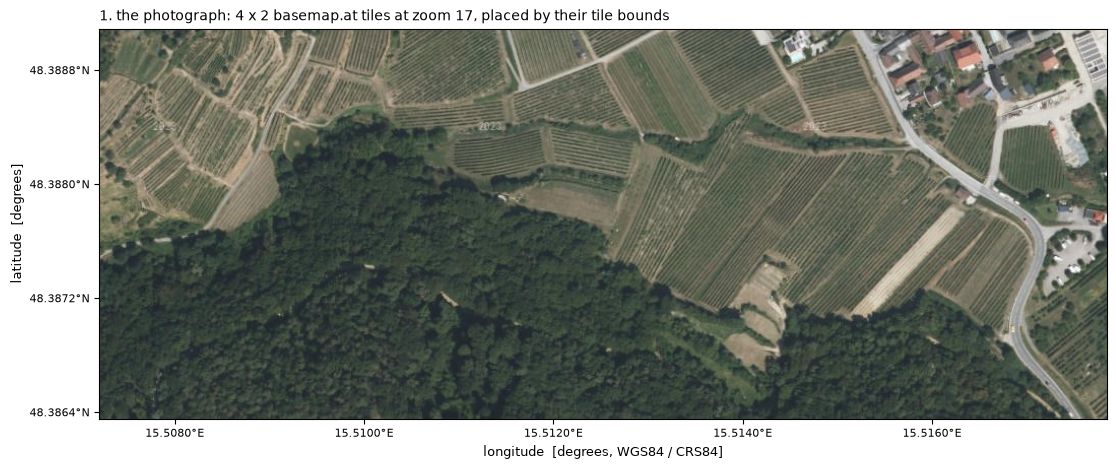

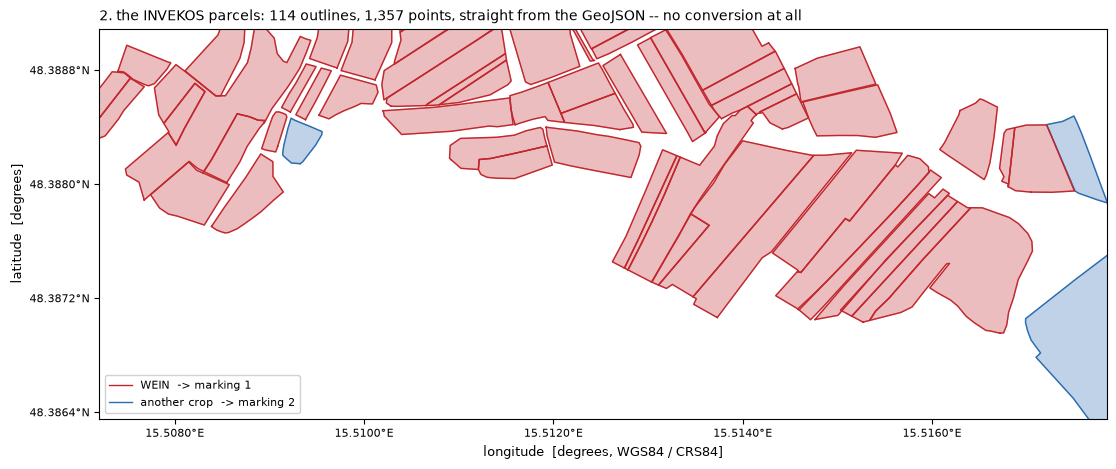

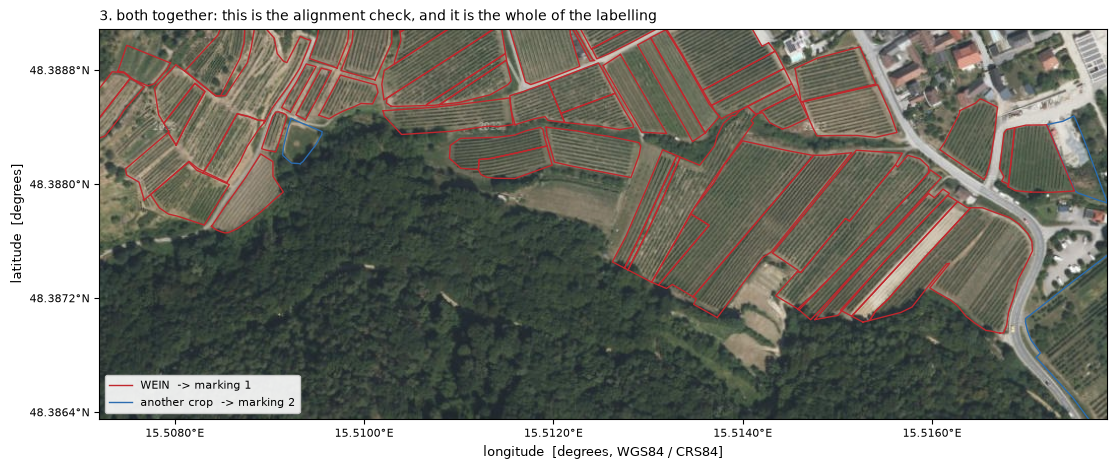

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

north, west = tile_deg(TX, TY)                               # degrees at the top-left tile corner
south, east = tile_deg(TX + RECT[0] / TILE, TY + RECT[1] / TILE)   # ... and at the far corner
EXTENT = (west, east, south, north)                          # where to place the image, in degrees
ASPECT = 1 / math.cos(math.radians((north + south) / 2))     # so 100 m east looks like 100 m north
WEIN, OTHER = "#c1272d", "#2b6cb0"                           # one colour per marking value, in both plots


def rings_of(f):
    """A parcel is one polygon or several. Each is a list of rings; a ring is a list of points."""
    g = f["geometry"]
    # A Polygon's coordinates are already a list of rings; a MultiPolygon's are a list of those.
    return g["coordinates"] if g["type"] == "Polygon" else [r for poly in g["coordinates"] for r in poly]


def degree_axes(title):
    """One set of axes in degrees, labelled the way both sources label their coordinates."""
    fig, ax = plt.subplots(figsize=(13, 5.2))
    ax.set_xlim(west, east)                                  # the plot spans exactly our rectangle
    ax.set_ylim(south, north)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_xlabel("longitude  [degrees, WGS84 / CRS84]", fontsize=9)
    ax.set_ylabel("latitude  [degrees]", fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(7))               # about 7 ticks across
    ax.yaxis.set_major_locator(MaxNLocator(4))               # about 4 up the side
    # A tick is a bare number until you say what it means; these two lines say degrees east/north.
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.4f}°E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.4f}°N"))
    ax.tick_params(labelsize=8)
    return fig, ax


def draw_parcels(ax, fill):
    """Every ring of every parcel, plotted from the raw degrees. Red = WEIN, blue = anything else."""
    labelled = set()                                         # so each colour gets one legend entry
    for f in raw["features"]:
        wein = f["properties"]["snar_bezeichnung"] == "WEIN"     # the one property we use
        colour, name = (WEIN, "WEIN  -> marking 1") if wein else (OTHER, "another crop  -> marking 2")
        for ring in rings_of(f):
            lon = [point[0] for point in ring]               # longitude is the FIRST number
            lat = [point[1] for point in ring]               # latitude the second
            if fill:
                ax.fill(lon, lat, color=colour, alpha=0.30)  # tinted area, for the parcels-only plot
            ax.plot(lon, lat, color=colour, lw=1.0, label=None if name in labelled else name)
            labelled.add(name)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)


# 1 -- the ground
fig, ax = degree_axes("1. the photograph: 4 x 2 basemap.at tiles at zoom 17, placed by their tile bounds")
ax.imshow(photo, extent=EXTENT, aspect=ASPECT)               # the array, stretched onto degree axes
plt.show()

if raw is None:
    print("no parcel answer on this route, so pictures 2 and 3 are skipped")
else:
    # 2 -- what the register claims, drawn from the raw coordinates and nothing else
    points = sum(len(r) for f in raw["features"] for r in rings_of(f))     # how many corners in total
    fig, ax = degree_axes(f"2. the INVEKOS parcels: {len(raw['features'])} outlines, {points:,} points, "
                          f"straight from the GeoJSON -- no conversion at all")
    ax.set_aspect(ASPECT)                                    # no image here, so set it by hand
    draw_parcels(ax, fill=True)
    plt.show()

    # 3 -- the claim on the ground it is a claim about
    fig, ax = degree_axes("3. both together: this is the alignment check, and it is the whole of the labelling")
    ax.imshow(photo, extent=EXTENT, aspect=ASPECT)
    draw_parcels(ax, fill=False)                             # outlines only, so the ground stays visible
    plt.show()

**Read picture 3 out loud before moving on.** Every red outline is a farmer's declaration, not
a measurement of vines. The forest across the bottom has no outline because nobody claims a
subsidy for forest --- and in the INVEKOS marking that becomes a **0**, which we are about to turn into
*not vineyard*. That step is a decision, and it happens in picture 3, not in the model.

## 0b. What INVEKOS actually sent, before it became a marking

Nothing further down depends on these two cells, so run them here or at the end, whichever the
clock allows. But somebody has to look at the raw answer once, because **every label in this
notebook is counted out of it**, and because the INVEKOS marking is the part of this data that
people wrote down by hand.

The parcels come from an **OGC API --- Features** endpoint: a plain HTTP API that answers with
**GeoJSON**. One answer is a `FeatureCollection`: a list of `Feature`s, each with a `geometry`
(the outline) and `properties` (what was declared about it). The answer also reports how many
parcels matched in total, and hands back a `next` link --- which is why the loader keeps asking
until it has them all.

In [5]:
if raw is None:
    print("No saved answer here: this run cut the rectangle out of the strip on disk, so nothing\n"
          "was asked of INVEKOS. Run the loader once with a network and this section fills in.")
else:
    env = raw["mlr1ilv"]                        # what the loader recorded about the request itself
    print("THE REQUEST")
    print(f"  {env['request']}\n")              # the URL, with the bounding box and the paging

    print("THE ENVELOPE  (the first page, with the 100 features taken out)")
    for k, v in env["first_page"].items():      # type, numberMatched, numberReturned, timeStamp, links
        print(f"  {k:<16}{str(v)[:96]}")        # cut long values off: links are very long
    print(f"  {'(collected)':<16}{len(raw['features'])} parcels, after following the next link\n")

    # The response header that says which coordinate system the numbers below are in.
    crs = next((v for k, v in env["headers"].items() if k.lower() == "content-crs"), "(not sent)")
    print(f"COORDINATES  the answer is in {crs}")
    print("             = degrees on the WGS84 ellipsoid, LONGITUDE first, latitude second\n")

    f0 = raw["features"][0]                     # one parcel, the first one the service sent
    g = f0["geometry"]                          # its outline
    print("ONE FEATURE, AS IT ARRIVED")
    print(f"  id        {f0['id']}")
    print(f"  geometry  {g['type']}, {len(g['coordinates'])} ring(s), "
          f"{len(g['coordinates'][0])} points in the outer ring")
    print("  the first three points of that ring, verbatim:")
    for lon, lat, *_ in g["coordinates"][0][:3]:    # *_ swallows an elevation, if one is ever sent
        print(f"      [{lon}, {lat}]")
    print("\n  properties:")
    for k, v in f0["properties"].items():       # everything the register records about this parcel
        print(f"      {k:<24}{v!r}"[:104])      # !r shows the type: '901' is text, 901 would be a number

THE REQUEST
  https://gis.lfrz.gv.at/api/geodata/i009501/ogc/features/v1/collections/i009501:invekos_schlaege_2025_1_polygon/items?bbox=15.5052021484375,48.38435420778455,15.519845153808594,48.39109015961601&limit=100&startIndex=0&f=application%2Fgeo%2Bjson

THE ENVELOPE  (the first page, with the 100 features taken out)
  type            FeatureCollection
  numberMatched   114
  numberReturned  100
  timeStamp       2026-09-30T09:56:29.670Z
  links           [{'title': 'Next page', 'type': 'application/geo+json', 'rel': 'next', 'href': 'https://gis.lfrz
  (collected)     114 parcels, after following the next link

COORDINATES  the answer is in <http://www.opengis.net/def/crs/OGC/1.3/CRS84>
             = degrees on the WGS84 ellipsoid, LONGITUDE first, latitude second

ONE FEATURE, AS IT ARRIVED
  id        invekos_schlaege_2025_1_polygon.24796
  geometry  Polygon, 1 ring(s), 18 points in the outer ring
  the first three points of that ring, verbatim:
      [15.50810819, 48.38879361]


### How to read that

A pair like `[15.50811, 48.38879]` is **longitude first, latitude second**, degrees on the
WGS84 ellipsoid --- the `Content-Crs` line above is the service saying so, and GeoJSON fixes
that order on purpose ([RFC 7946 §3.1.1](https://www.rfc-editor.org/rfc/rfc7946#section-3.1.1)).
That is the one detail worth carrying out of here: `EPSG:4326`, the code most people write when
they mean "WGS84", is officially **latitude first**, so a library that hands the pairs over the
other way round will put the Wachau in Yemen and still draw you a convincing picture.

Our pixels are a different grid again --- the photograph's map tiles --- and `to_pixel()` in the
loader is that conversion, five lines of arithmetic. The next cell walks one corner of one
parcel through it and then checks the answer against a number the service reports itself: the
declared area in hectares. Whether the conversion is right is a question you can settle, so
settle it rather than trusting it.

**The properties.** We use exactly one, `snar_bezeichnung`, the declared crop. `snar_code` is
the same thing as a number, `sl_flaeche_brutto_ha` the declared gross area, `fs_kennung` and
`geo_id` the register's own keys, `inspire_id` and `gml_id` the EU-wide identifiers, and
`gml_geom` is a Java object's address that escaped into the JSON --- open data has junk in it,
and that is worth seeing once.

**Where the documentation is**

| what | where |
|---|---|
| the collection, readable in a browser | `…/collections/i009501:invekos_schlaege_2025_1_polygon?f=text/html` |
| its field list, and what may be filtered on | the same URL + `/queryables?f=text/html` |
| the API standard, and the answer format | [OGC API --- Features](https://docs.ogc.org/is/17-069r4/17-069r4.html) · [RFC 7946](https://www.rfc-editor.org/rfc/rfc7946) |
| the licence | INVEKOS Schläge 2025, AMA, [CC BY 3.0 AT](https://creativecommons.org/licenses/by/3.0/at/) |

In [6]:
if raw is not None:
    print("WHAT WAS DECLARED IN OUR BOX  (this is where the marking values come from)")
    # Counter tallies how often each (code, name) pair occurs across the 114 parcels.
    counts = collections.Counter((f["properties"]["snar_code"], f["properties"]["snar_bezeichnung"])
                                 for f in raw["features"])
    for (snar_code, name), n in counts.most_common():       # most common crop first
        mark = "-> marking 1" if name == "WEIN" else "-> marking 2"      # our own rule, not theirs
        print(f"  {snar_code:>5}  {name:<34}{n:>4} parcels   {mark}")

    print("\nONE CORNER, ALL THE WAY THROUGH")
    # [0] the first parcel, ["coordinates"][0] its outer ring, [0] the first point, [:2] lon and lat.
    lon, lat = raw["features"][0]["geometry"]["coordinates"][0][0][:2]
    across_px, down_px = to_pixel(lat, lon)             # the same conversion the loader used to draw the marking
    print(f"  as it arrived      lon {lon}, lat {lat}   (longitude first)")
    print(f"  on our pixel grid  {across_px:.1f} across, {down_px:.1f} down")
    print(f"  the marking there     {marking[int(down_px), int(across_px)]}")     # down first: arrays are [down, across]
    print(f"  the patch it is in down {int(down_px) // 32}, across {int(across_px) // 32}   (32 px = 25 m)")

    print("\nIS THE CONVERSION RIGHT?  Compare the area we compute with the area declared.")
    print(f"  {'parcel':<10}{'declared ha':>12}{'from our pixels':>17}{'difference':>12}")
    for f in raw["features"][:6]:
        # Every corner of the outer ring, converted to pixels: the parcel as we drew it.
        ring = np.array([to_pixel(lat_, lon_) for lon_, lat_, *_ in
                         f["geometry"]["coordinates"][0]])         # outer ring only
        x, y_ = ring[:, 0], ring[:, 1]
        # The shoelace formula: the area of any polygon, from its corners alone.
        area_px = 0.5 * abs(np.dot(x, np.roll(y_, -1)) - np.dot(y_, np.roll(x, -1)))
        ours = area_px * 0.793 ** 2 / 10_000                       # across -> m^2 -> hectares
        declared = f["properties"]["sl_flaeche_brutto_ha"]         # what the register says
        print(f"  {f['id'].split('.')[-1]:<10}{declared:>12.4f}{ours:>17.4f}"
              f"{(ours - declared) / declared * 100:>11.1f}%")

WHAT WAS DECLARED IN OUR BOX  (this is where the marking values come from)
    901  WEIN                               108 parcels   -> marking 1
    716  MÄHWIESE/-WEIDE ZWEI NUTZUNGEN       3 parcels   -> marking 2
    813  MARILLEN                             1 parcels   -> marking 2
    771  GRÜNBRACHE                           1 parcels   -> marking 2
    817  TAFELÄPFEL                           1 parcels   -> marking 2

ONE CORNER, ALL THE WAY THROUGH
  as it arrived      lon 15.50810819, lat 48.38879361   (longitude first)
  on our pixel grid  84.4 across, 41.6 down
  the marking there     1
  the patch it is in down 1, across 2   (32 px = 25 m)

IS THE CONVERSION RIGHT?  Compare the area we compute with the area declared.
  parcel     declared ha  from our pixels  difference
  24796           0.1864           0.1863       -0.1%
  93567           0.2940           0.2938       -0.1%
  93621           0.3266           0.3263       -0.1%
  93756           0.3238           0.3235  

**Two things just happened, and both belong in a why-trail.**

The areas agree to about a tenth of a percent. That is not a formality: it is the only evidence
we have that the coordinates were read in the right order and landed on the right pixels. Had
we swapped longitude and latitude, or mixed up the tile origin, the marking would still look
plausible on screen and every number in this notebook would be quietly wrong. **A check that
compares your own computation against a number somebody else published is worth ten checks
that compare your code against itself.**

And look at what the register actually declared: vines, yes --- and apricots, a meadow, a
fallow strip, table apples. All of those became **marking 2**, "another crop", because *we* wrote
`== "WEIN"` in the loader. Nobody handed us a vineyard/not-vineyard label; we made one out of a
subsidy form. The Wachau's apricots are famous, and in our label they are a rounding error.

## 1. The live demo: the model that reports 92 % and predicts nothing

The instruction to the LLM was *classify each piece of ground as vineyard or not*, and it
**cleaned the data** first: it kept only the pixels that lie inside a registered parcel.

Predict before running: what share of *that* ground is vineyard?

In [7]:
# marking is HEIGHT x WIDTH. marking > 0 is True wherever a parcel was declared, so this keeps
# every pixel inside a parcel and throws the rest away: one long 1-D array of marking numbers.
inside_parcel = marking[marking > 0]
# == 1 turns "is this WEIN?" into True/False; astype(int) turns that into 1 and 0, the label y.
y_B = (inside_parcel == 1).astype(int)

# The mean of an array of 1s and 0s IS the share of 1s: what fraction of this ground is vineyard.
share = y_B.mean()
# The baseline: always predict the more common of the two marking. It is right that often.
baseline_B = max(share, 1 - share)
print(f"data points kept: {len(y_B):,} pixels, {share*100:.1f}% of them vineyard")
print(f"baseline: the constant prediction 'vineyard' is right {baseline_B*100:.1f}% of the time")


# The learned hypothesis the LLM handed back, written out in full. A hypothesis is a map from a
# feature vector to a prediction, and this one ignores its input completely.
def h_llm(x):
    return 1                                # ... vineyard. For every data point. Always.


# Applying that map to every data point is the same as an array of 1s the same length as y_B.
pred = np.ones_like(y_B)
# pred == y_B is True where the prediction is right; its mean is the accuracy.
acc = (pred == y_B).mean()
print(f"\naccuracy of the learned hypothesis {acc:.3f}")
print(f"baseline                            {baseline_B:.3f}")
# The only number that carries information: how far the hypothesis beats the constant one.
print(f"difference                          {(acc - baseline_B)*100:+.1f}")

data points kept: 144,862 pixels, 92.2% of them vineyard
baseline: the constant prediction 'vineyard' is right 92.2% of the time

accuracy of the learned hypothesis 0.922
baseline                            0.922
difference                          +0.0


**Stop here.** The accuracy is real, the code is correct, and the result is worthless. Ask:

- What did *keep only registered parcels* throw away? Every forest, roof and road: the only
  ground that is **not** vineyard.
- What is left is farmland, and above Rossatz farmland is mostly vines.
- So the constant prediction already scores 92 %, and the learned hypothesis scores the same.

An accuracy is unreadable until you put the baseline next to it.

## 2. Count the data points that were thrown away, and the problem comes back

Now every patch of the photograph is a data point, and *no parcel* counts as *not vineyard*.

In [8]:
P = 32                                          # one patch is 32 x 32 pixels = 25 x 25 m of ground
H, W = marking.shape                             # HEIGHT and WIDTH of the marking, in pixels
n_down, n_across = H // P, W // P                         # how many patches fit: 12 down, 31 across

# Cut the marking into patches without copying anything. reshape splits HEIGHT into (n_down, P) and
# WIDTH into (n_across, P); transpose puts the two patch indices first; the last reshape flattens each
# patch's 32 x 32 pixels into one list of 1024 marking numbers.
cover = marking.reshape(n_down, P, n_across, P).transpose(0, 2, 1, 3).reshape(n_down, n_across, -1)
# For each patch: what share of its 1024 pixels is vineyard. ravel() lays the grid out as one
# long list, so patch number i is the same i we use in X later.
vine_share = (cover == 1).mean(axis=2).ravel()

print(f"{n_down} x {n_across} = {n_down*n_across:,} patches\n")
print("A third decision nobody announced: when is a patch 'a vineyard'?\n")
print(f"  {'vineyard if cover above':<26}{'positives':>12}{'baseline':>12}")
for thr in (0.25, 0.50, 0.75):                    # three defensible thresholds, three datasets
    y_thr = (vine_share > thr).astype(int)          # the marking this threshold would produce
    # mean of the marking = share of vineyard patches; the baseline follows the bigger class.
    print(f"  {thr:>24.0%}  {y_thr.mean()*100:>11.1f}%{max(y_thr.mean(), 1-y_thr.mean())*100:>11.1f}%")

# Patches that are neither almost-all vine nor almost-no vine. No threshold makes them honest.
mixed = 1 - float(((vine_share < 0.05) | (vine_share > 0.95)).mean())
print(f"\n{mixed*100:.0f}% of the patches are genuinely mixed (5-95% vine). No threshold cleans them.")

y = (vine_share > 0.50).astype(int)             # the decision we take for the rest of today

12 x 31 = 372 patches

A third decision nobody announced: when is a patch 'a vineyard'?

  vineyard if cover above      positives    baseline
                       25%         43.3%       56.7%
                       50%         35.8%       64.2%
                       75%         28.0%       72.0%

33% of the patches are genuinely mixed (5-95% vine). No threshold cleans them.


## 3. DATA: what is one data point?

Three defensible answers on one photograph. Your choice sets *m*, the features, **and** what a
label can mean. Ask the room for the answer before the cell runs.

In [9]:
# Nothing is computed here: the three lines are the same photograph, counted three ways.
print(f"{'a data point is':<18}{'m':>14}{'d':>12}   what its label can mean")
print(f"{'-'*18}{'-'*14:>14}{'-'*12:>12}   {'-'*34}")
# One pixel per data point: m is every pixel, and its features are its three colour numbers.
print(f"{'one pixel':<18}{H*W:>14,}{3:>12}   is this 0.8 m spot vine")
# One patch per data point: m is the patch count, d the raw numbers inside one patch.
print(f"{'one 25 m patch':<18}{n_down*n_across:>14,}{P*P*3:>12}   is this square mostly vine")
# The whole image as one data point: m = 1, and one data point cannot be learned from.
print(f"{'the whole image':<18}{1:>14,}{H*W*3:>12}   nothing: m = 1, there is nothing to learn from")

print("\nA pixel is three numbers: how red, how green, how blue.")
print("Grass is green. A meadow is green. A vineyard is green.")
print("What makes a vineyard look like a vineyard is the STRIPES, and a stripe is a")
print("pattern across pixels. One pixel cannot show it.")

a data point is                m           d   what its label can mean
--------------------------------------------   ----------------------------------
one pixel                380,928           3   is this 0.8 m spot vine
one 25 m patch               372        3072   is this square mostly vine
the whole image                1     1142784   nothing: m = 1, there is nothing to learn from

A pixel is three numbers: how red, how green, how blue.
Grass is green. A meadow is green. A vineyard is green.
What makes a vineyard look like a vineyard is the STRIPES, and a stripe is a
pattern across pixels. One pixel cannot show it.


## 4. FEATURES and LABEL: the table the method actually sees

A patch is 3,072 raw numbers: 4.6 MB on this rectangle, and half a gigabyte on the whole
strip. So summarise each patch instead: three colour means, how much the brightness varies
inside the patch (contrast), how green it is, and how much the brightness changes down and
across it (the two gradients, which is where a stripe shows up).

The cell is instant on the rectangle and takes about half a minute on the whole strip. It is
the whole of A1's step (b), for one choice of data point.

In [10]:
t0 = time.perf_counter()                                # so we can print how long this took
bands, xs, ys = [], [], []                              # collected per band, joined at the end
for by in range(n_down):                                    # one band of patches at a time
    # 32 lines of the photograph, cut into the n_across patches that sit side by side in them:
    # (32, WIDTH, 3) -> (32, n_across, 32, 3) -> (n_across, 32, 32, 3), so axis 0 is "which patch".
    block = photo[by*P:(by+1)*P].astype(np.float32).reshape(P, n_across, P, 3).transpose(1, 0, 2, 3)
    grey = block.mean(3)                                # average the 3 colours -> brightness
    # Seven numbers per patch. Every .mean((1, 2)) averages over the 32 x 32 pixels of a patch,
    # leaving one number per patch; np.stack puts the seven side by side as columns.
    bands.append(np.stack([
        block[..., 0].mean((1, 2)),                                       # R: mean red
        block[..., 1].mean((1, 2)),                                       # G: mean green
        block[..., 2].mean((1, 2)),                                       # B: mean blue
        grey.std((1, 2)),                                                 # contrast: how uneven
        ((block[..., 1] - block[..., 0]) /
         (block[..., 1] + block[..., 0] + 1e-6)).mean((1, 2)),            # greenness: green vs red
        np.abs(np.diff(grey, axis=1)).mean((1, 2)),                       # grad_v: change downwards
        np.abs(np.diff(grey, axis=2)).mean((1, 2))], 1))                  # grad_h: change sideways
    xs.append(np.arange(n_across))                            # which x each patch of this band has
    ys.append(np.full(n_across, by))                          # ... and the y they all share

X = np.concatenate(bands).astype(np.float32)            # the feature table: m data points x d
patch_across = np.concatenate(xs)                            # where data point i sits, across
patch_down = np.concatenate(ys)                            # where data point i sits, downwards
FEATURES = ["R", "G", "B", "contrast", "greenness", "grad_v", "grad_h"]   # the column names

print(f"[built the table in {time.perf_counter() - t0:.1f} s]\n")
print(f"X {X.shape}   m = {X.shape[0]:,} data points, d = {X.shape[1]} features")
print(f"y {y.shape}   {y.mean()*100:.1f}% of the labels are vineyard\n")

DECIMALS = [1, 1, 1, 1, 3, 1, 1]                        # decimals per column, as on the slide
print("down,across," + ",".join(f"{n:>9}" for n in FEATURES) + ",  label")
# np.where gives the positions of the six patches at down = 3, x = 19..24: six lines of the table.
for i in np.where((patch_down == 3) & (patch_across >= 19) & (patch_across < 25))[0]:
    print(f"{patch_down[i]:4d},{patch_across[i]:6d}," +
          ",".join(f"{v:9.{k}f}" for v, k in zip(X[i], DECIMALS)) + f",{y[i]:7d}")

[built the table in 0.0 s]

X (372, 7)   m = 372 data points, d = 7 features
y (372,)   35.8% of the labels are vineyard

down,across,        R,        G,        B, contrast,greenness,   grad_v,   grad_h,  label
   3,    19,     98.5,    102.3,     85.7,     13.9,    0.021,      7.6,      9.9,      1
   3,    20,     96.5,    100.8,     85.3,     18.4,    0.030,      7.9,      6.7,      0
   3,    21,    103.1,    104.1,     88.8,     24.2,    0.017,      8.7,      6.6,      0
   3,    22,    107.8,    107.7,     92.9,     31.1,    0.014,     13.4,      7.9,      0
   3,    23,    114.6,    112.8,     96.5,     25.8,    0.000,     14.1,      6.5,      1
   3,    24,    127.1,    126.3,    111.8,     35.8,    0.000,     13.5,      8.0,      0


**One line is one data point.** The middle columns are its features **x**, the last column is
its label *y*. Point at the first two lines: almost the same colours, different labels. That
is the difficulty, in six lines.

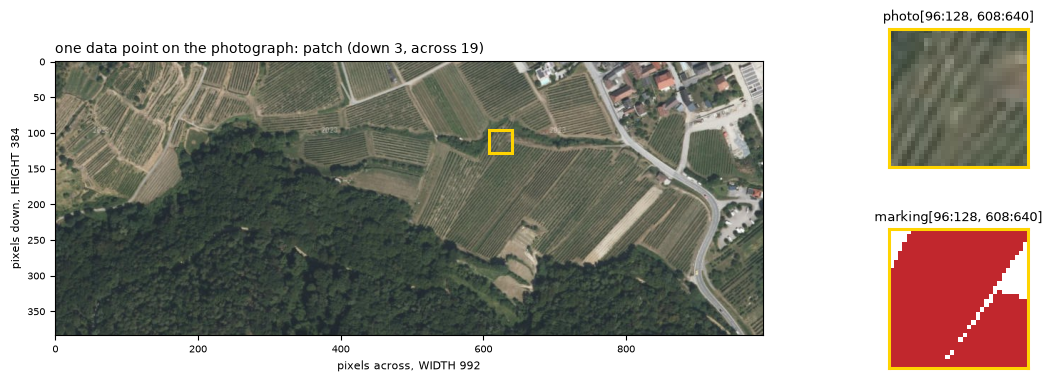

the photograph gives the features:   32 x 32 x 3 = 3,072 raw numbers, summarised as d = 7
   R=98.506  G=102.263  B=85.688  contrast=13.940  greenness=0.021  grad_v=7.559  grad_h=9.914

the INVEKOS marking gives the label: 930 of the 1,024 pixels are WEIN = 90.8% cover
   above our 50% threshold, so y = 1     (25% would give 1, 75% would give 1)

and there are 12 x 31 = 372 of these squares, side by side, covering the whole photograph.


In [11]:
from matplotlib.colors import ListedColormap          # for drawing the three marking values

# One data point, located. This is the patch on the first line of the table above.
down, across = 3, 19                                   # its place in the 12 x 31 grid of patches
top, left = down * P, across * P                       # ... and where that is in pixels
i = down * n_across + across                                 # the place of that patch in X and in y

# Three panels: the whole photograph on the left, and the same square twice on the right --
# once as the camera saw it, once as the register marked it.
fig = plt.figure(figsize=(13, 4.4))
grid = fig.add_gridspec(2, 2, width_ratios=[3.4, 1], hspace=0.45)
ax_all = fig.add_subplot(grid[:, 0])             # spans both lines of the right column
ax_photo = fig.add_subplot(grid[0, 1])
ax_mask = fig.add_subplot(grid[1, 1])

ax_all.imshow(photo)                             # the whole photograph, in pixels
# A rectangle at (left, top), P wide and P high, not filled, so the ground stays visible.
ax_all.add_patch(plt.Rectangle((left, top), P, P, fill=False, color="#ffd400", lw=2.2))
ax_all.set_title(f"one data point on the photograph: patch (down {down}, across {across})", fontsize=10, loc="left")
ax_all.set_xlabel(f"pixels across, WIDTH {photo.shape[1]}", fontsize=8)
ax_all.set_ylabel(f"pixels down, HEIGHT {photo.shape[0]}", fontsize=8)
ax_all.tick_params(labelsize=7)

# Top right: those 32 x 32 pixels of the photograph, drawn without smoothing.
ax_photo.imshow(photo[top:top + P, left:left + P], interpolation="nearest")
ax_photo.set_title(f"photo[{top}:{top + P}, {left}:{left + P}]", fontsize=9)

# Bottom right: the SAME 32 x 32 pixels of the INVEKOS marking. Same colours as picture 3 of
# section 0a: white where nobody declared anything, red WEIN, blue another crop.
mark = ListedColormap(["#ffffff", "#c1272d", "#2b6cb0"])
# vmin and vmax pin 0, 1, 2 to those three colours even when a patch holds only one of them.
ax_mask.imshow(marking[top:top + P, left:left + P], cmap=mark, vmin=0, vmax=2, interpolation="nearest")
ax_mask.set_title(f"marking[{top}:{top + P}, {left}:{left + P}]", fontsize=9)

for ax in (ax_photo, ax_mask):                   # pixel numbers inside one patch say nothing
    ax.set_xticks([])
    ax.set_yticks([])
    for edge in ax.spines.values():              # frame both in the same yellow as the rectangle
        edge.set_color("#ffd400")
        edge.set_linewidth(2.2)
plt.show()

# The label of this data point is not given to us: it is counted out of the square below left.
vine_pixels = int((marking[top:top + P, left:left + P] == 1).sum())
print(f"the photograph gives the features:   {P} x {P} x 3 = {P*P*3:,} raw numbers, "
      f"summarised as d = {len(FEATURES)}")
print("   " + "  ".join(f"{n}={v:.3f}" for n, v in zip(FEATURES, X[i])))
print(f"\nthe INVEKOS marking gives the label: {vine_pixels:,} of the {P*P:,} pixels are WEIN "
      f"= {vine_share[i]*100:.1f}% cover")
print(f"   above our 50% threshold, so y = {y[i]}     (25% would give "
      f"{int(vine_share[i] > 0.25)}, 75% would give {int(vine_share[i] > 0.75)})")
print(f"\nand there are {n_down} x {n_across} = {n_down*n_across} of these squares, side by side, covering the whole"
      f" photograph.")

The square is the data point. Everything the method will ever know about that piece of ground
is the seven numbers underneath it --- not the picture, and not where it sits. Move the square
one step across and you have the next data point, with its own seven numbers and its own label.

## 5. HYPOTHESIS: a map from features to a prediction

Here are the two patches from the slide, as the method sees them.

vineyard (down 2, across 22)R=125.562  G=118.906  B=100.817  contrast= 18.406  greenness= -0.028  grad_v= 22.539  grad_h=  6.575   label 1
forest   (down 9, across 1)R= 46.243  G= 57.952  B= 53.896  contrast=  6.259  greenness=  0.114  grad_v=  3.205  grad_h=  3.044   label 0


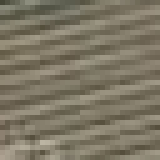

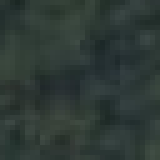

In [12]:
def show(name, down, across):
    """Print the feature vector of the patch at (down, across) and hand back its picture."""
    i = down * n_across + across                            # patches are stored band by band, so this is its place in X
    # zip pairs each feature name with its number, so the line reads R=... G=... B=...
    print(f"{name:<24}" + "  ".join(f"{n}={v:7.3f}" for n, v in zip(FEATURES, X[i])) +
          f"   label {y[i]}")
    # Cut those 32 x 32 pixels back out of the photograph and blow them up 5x. NEAREST keeps the
    # pixels as visible squares instead of smoothing them away.
    return Image.fromarray(photo[down*P:(down+1)*P, across*P:(across+1)*P]).resize((160, 160), Image.NEAREST)


vineyard_patch = show("vineyard (down 2, across 22)", 2, 22)    # all vineyard, the stripiest patch here
other_patch = show("forest   (down 9, across 1)", 9, 1)         # no parcel at all: forest
display(vineyard_patch, other_patch)                    # show both pictures under the numbers

Two numbers do the talking: `grad_v` is 22.5 on the vineyard patch against 3.2 on the forest,
because the vines are planted in stripes. And the forest is the **greener** of the two.

Now write a hypothesis by hand. *Greener and stripier means vineyard* is the one on the slide.
A hypothesis is just a map: features in, one prediction out.

In [13]:
def h_greener(x):
    """The hypothesis people propose first: greener than average means vineyard."""
    # x is one feature vector. Pick out its greenness, compare, and return 1 or 0 -- a prediction.
    return int(x[FEATURES.index("greenness")] > 0.02)


# Try it on the two patches we just looked at, and say whether it got each one right.
for name, (down, across) in (("vineyard (down 2, across 22)", (2, 22)), ("forest   (down 9, across 1)", (9, 1))):
    i = down * n_across + across                            # the place of that patch in X and y
    print(f"{name}:  h(x) = {h_greener(X[i])}   label = {y[i]}"
          f"   {'correct' if h_greener(X[i]) == y[i] else 'WRONG'}")

# The same comparison applied to all 372 data points at once: one column of X against a number.
pred = (X[:, FEATURES.index("greenness")] > 0.02).astype(int)
acc = (pred == y).mean()                        # share of data points this hypothesis gets right
base = max(y.mean(), 1 - y.mean())              # what the constant prediction already scores
print(f"\nover all {len(y):,} data points: accuracy {acc:.3f}, baseline {base:.3f},"
      f" difference {(acc-base)*100:+.1f}")

vineyard (down 2, across 22):  h(x) = 0   label = 1   WRONG
forest   (down 9, across 1):  h(x) = 1   label = 0   WRONG

over all 372 data points: accuracy 0.242, baseline 0.642, difference -40.1


**It is worse than the constant prediction.** Around here the vineyards are *less* green than
the forest, so the hypothesis everyone proposes first has the sign backwards. This is the
moment of the session: a hypothesis is a claim, and a claim gets checked, not admired.

## 6. MODEL: the set of hypotheses to choose from

One hypothesis is not interesting. A **model** is a whole set of them, and training picks one.
Take the simplest set imaginable: pick one feature, pick a threshold, predict vineyard on one
side of it. Every choice of feature and threshold is one candidate hypothesis.

In [14]:
def average_loss(pred, y):
    """The 0/1 loss, averaged over the data points: the share of wrong predictions."""
    # pred != y is True on every mistake; the mean of those Trues is the share of mistakes.
    return float((pred != y).mean())


t0 = time.perf_counter()
# The baseline as a loss rather than an accuracy, so the column below compares like with like.
print(f"the baseline, as an average loss: {1 - base:.4f}\n")
print(f"{'feature':<12}{'best hypothesis in the set':<38}{'average loss':>13}{'vs baseline':>13}")
best_overall = None                             # the best (loss, feature, threshold, direction)
for j, name in enumerate(FEATURES):             # j walks the columns of X: one feature at a time
    best = None                                 # the best hypothesis using THIS feature
    # 99 thresholds, placed so that 1%, 2%, ... of the data points fall below each one.
    for thr in np.percentile(X[:, j], np.arange(1, 100)):
        for above in (True, False):             # "vineyard if above thr" and "vineyard if below thr"
            # One candidate hypothesis, applied to all m data points in a single comparison.
            pred = ((X[:, j] > thr) if above else (X[:, j] <= thr)).astype(int)
            loss = average_loss(pred, y)        # how wrong it is, averaged over the data points
            if best is None or loss < best[0]:  # keep it only if it beats what we have
                best = (loss, thr, above)
    loss, thr, above = best                       # the winner among this feature's 198 candidates
    rel = ">" if above else "<="                # how to write the comparison out
    print(f"{name:<12}{'vineyard if ' + name + ' ' + rel + f' {thr:.3f}':<38}"
          f"{loss:>13.4f}{(1-base) - loss:>+13.4f}")
    if best_overall is None or loss < best_overall[0]:   # and the winner across all features
        best_overall = (loss, j, thr, above)
print(f"\n[searched {7 * 99 * 2} candidate hypotheses in {time.perf_counter() - t0:.1f} s]")

the baseline, as an average loss: 0.3575

feature     best hypothesis in the set             average loss  vs baseline
R           vineyard if R > 90.445                       0.2366      +0.1210
G           vineyard if G > 95.393                       0.2366      +0.1210
B           vineyard if B > 80.259                       0.2312      +0.1263
contrast    vineyard if contrast > 12.771                0.3333      +0.0242
greenness   vineyard if greenness <= 0.032               0.2097      +0.1478
grad_v      vineyard if grad_v > 9.024                   0.2151      +0.1425
grad_h      vineyard if grad_h > 7.993                   0.2177      +0.1398

[searched 1386 candidate hypotheses in 0.0 s]


Read the table with the room:

- `contrast` on its own is worth almost nothing: it beats the constant prediction by two
  points, on the data it was chosen on.
- `greenness` wins, with the comparison the wrong way round: *less* green means vineyard.
- The two gradients, which is where a stripe shows up, come next, and are the two features
  that survive into section 8.

The winner of that table is the result of **searching a set of hypotheses for the one with the
smallest average loss**. That search is what training is.

## 7. LOSS: the number that decides what "wrong" costs

The 0/1 loss counts every mistake the same. A subsidy office does not: paying for a vineyard
that is not there is a different mistake from missing one that is.

In [15]:
loss, j, thr, above = best_overall                # the hypothesis training just picked, unpacked
# Apply it once more, to get its actual predictions on every data point.
pred = ((X[:, j] > thr) if above else (X[:, j] <= thr)).astype(int)
# Its two kinds of mistake, counted separately. & is "and", elementwise over all m data points.
false_vineyard = int(((pred == 1) & (y == 0)).sum())     # said vineyard, was not
missed_vineyard = int(((pred == 0) & (y == 1)).sum())    # said not, was vineyard
print(f"the winning hypothesis: vineyard if {FEATURES[j]} {'>' if above else '<='} {thr:.3f}")
print(f"  false vineyard  {false_vineyard:>7,}      missed vineyard {missed_vineyard:>7,}\n")
print(f"{'what one mistake costs':<34}{'total cost':>12}")
# The same two counts, priced three ways. Only the prices change; the predictions do not.
for c_fp, c_fn in ((1, 1), (5, 1), (1, 5)):
    print(f"  a false vineyard {c_fp}, a missed one {c_fn}: {false_vineyard*c_fp + missed_vineyard*c_fn:>12,}")

the winning hypothesis: vineyard if greenness <= 0.032
  false vineyard       60      missed vineyard      18

what one mistake costs              total cost
  a false vineyard 1, a missed one 1:           78
  a false vineyard 5, a missed one 1:          318
  a false vineyard 1, a missed one 5:          150


Same data points, same predictions, three different answers to *how bad is this?* The loss is
where somebody's real costs enter the computation, and choosing it is not a technical detail.

## 8. ERM: training is minimizing the average loss

$$\hat{h} \;=\; \arg\min_{h \in \mathcal{H}} \; \frac{1}{m} \sum_{r=1}^{m}
L\big(y^{(r)}, h(\mathbf{x}^{(r)})\big)$$

We just did this by hand: we searched the set of threshold hypotheses for the one with the
smallest average loss. `fit()` does the same thing over a much larger set.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# True for every data point in the eastern third of the rectangle. This is the ground we keep
# back: the hypothesis never sees it while training, so its accuracy there means something.
east = patch_across >= 0.7 * n_across
# The model: every hypothesis of the form "threshold on a weighted sum of the seven features".
# StandardScaler first, so that features measured on different scales get a fair hearing.
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
# fit() IS the argmin on the slide: it searches that set for the smallest average loss.
pipe.fit(X[~east], y[~east])                     # ~east = everything that is not eastern

acc = pipe.score(X[east], y[east])               # accuracy on data points it never trained on
base_east = max(y[east].mean(), 1 - y[east].mean())      # the baseline on that same ground
print(f"trained on {(~east).sum():,} western patches, judged on {east.sum():,} eastern ones")
print(f"  accuracy {acc:.3f}   baseline {base_east:.3f}   difference {(acc-base_east)*100:+.1f}")

print("\nthe learned hypothesis, in full: one weight per feature, and an offset")
w = pipe[-1].coef_[0]                            # pipe[-1] is the LogisticRegression step
# Sort by size of the weight regardless of sign, so the features that matter come first.
for n, wi in sorted(zip(FEATURES, w), key=lambda p: -abs(p[1])):
    print(f"  {n:<12}{wi:+8.3f}")
print(f"  {'offset':<12}{pipe[-1].intercept_[0]:+8.3f}")

trained on 264 western patches, judged on 108 eastern ones
  accuracy 0.787   baseline 0.657   difference +13.0

the learned hypothesis, in full: one weight per feature, and an offset
  grad_v        +1.630
  grad_h        +1.360
  contrast      -1.329
  greenness     -1.246
  G             +0.349
  B             -0.129
  R             -0.073
  offset        -1.237


**This is the result of the day.** 0.787 against a baseline of 0.657: thirteen points, on data
points the training never saw, and the two gradients carry the most weight. Compare it with
the 92 % from section 1, which beat its baseline by nothing at all. Same photograph, same
labels, same method. The difference is a decision about what counts as a data point, and
nobody announced it.

Why the eastern third and not a random selection of patches? Because the number has to mean
something, and that is the whole of Session 2.

## Close

Three decisions today that are easy to mistake for facts:

1. **What is a data point?** A pixel, a patch, the whole image.
2. **What does an absent label mean?** INVEKOS lists farmland. *No parcel* means *nobody said*.
3. **When is a patch a vineyard?** Above 25 %, 50 % or 75 % cover.

Labels are made by people, for a purpose. INVEKOS exists to pay subsidies, not to train your
model.

**A1, due Wed 07.10, 23:59.** Build the table for two of pixel / patch / whole image, state
what an unpainted patch means, choose a threshold and say why, and state your baseline. Write
the why-trail as you go, and answer §5, the manual computation, on paper. A1 runs on the whole
strip, not on today's rectangle: `uv run get_wachau_photo.py` writes it once, and the numbers
you hand in are then the strip's, not the ones on the slides.

**Next: Session 2.** What `fit()` minimizes, why a training error is not evidence, and how to
compute an error that is worth reporting.

Moja cast: 

(384, 992) uint8 (array([0, 1, 2], dtype=uint8), array([236066, 133525,  11337]))


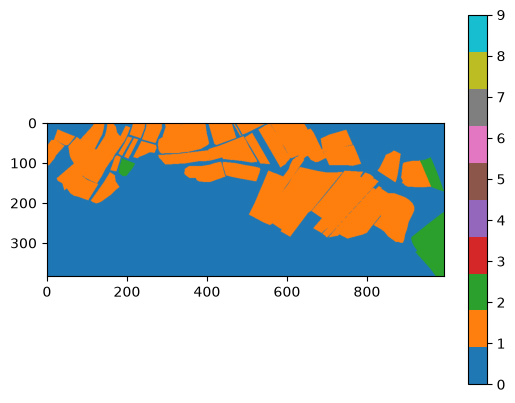

In [17]:
import numpy as np
from PIL import Image

m = np.array(Image.open("wachau_small_marking.png"))
print(m.shape, m.dtype, np.unique(m, return_counts=True))

import matplotlib.pyplot as plt
plt.imshow(m, cmap="tab10", vmin=0, vmax=9)
plt.colorbar()
plt.show()


In [18]:
Image.fromarray((m * 120).astype(np.uint8)).save("marking_preview.png")
